In [13]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [14]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,ac040_00000,0,235.296112,bald,1,38238.929443
1,1,ac040_00000,1,237.137360,bald,1,38238.929443
2,2,ac040_00000,2,258.125183,bald,1,38238.929443
3,3,ac040_00000,3,244.093140,bald,1,38238.929443
4,4,ac040_00000,4,253.526321,bald,1,38238.929443
...,...,...,...,...,...,...,...
4020,4020,ac040_00024,156,215.341187,random,5,34961.890579
4021,4021,ac040_00024,157,215.472809,random,5,34961.890579
4022,4022,ac040_00024,158,214.802200,random,5,34961.890579
4023,4023,ac040_00024,159,214.895020,random,5,34961.890579


In [15]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
3220,3220,ac040_00020,0,235.296112,random,1,36724.425171
3221,3221,ac040_00020,1,242.607391,random,1,36724.425171
3222,3222,ac040_00020,2,236.593216,random,1,36724.425171
3223,3223,ac040_00020,3,252.119232,random,1,36724.425171
3224,3224,ac040_00020,4,243.078766,random,1,36724.425171
...,...,...,...,...,...,...,...
4020,4020,ac040_00024,156,215.341187,random,5,34961.890579
4021,4021,ac040_00024,157,215.472809,random,5,34961.890579
4022,4022,ac040_00024,158,214.802200,random,5,34961.890579
4023,4023,ac040_00024,159,214.895020,random,5,34961.890579


In [16]:
def format_scientific_tight(value):
    """
    Formats a number using scientific notation without the + sign.
    """
    return f"{value:.2e}".replace('e+0', 'e').replace('e+', 'e')

In [17]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{format_scientific_tight(row.avg)} ± {format_scientific_tight(row.stdv)}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_43580/3633301443.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


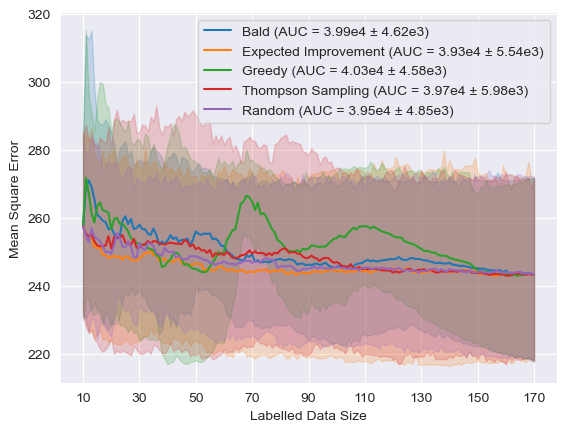

In [18]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")


current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
legend.set_title(None) 
    

for spine in ax.spines.values():
    spine.set_visible(False)